In [1]:
import subprocess, sys
print("=" * 60)
print("       CÀI ĐẶT THƯ VIỆN")
print("=" * 60)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torch-geometric", "rdkit"])
try:
    import torch
    import torch_geometric
    print(f"✅ PyTorch          : {torch.__version__}")
    print(f"✅ torch-geometric  : {torch_geometric.__version__}")
    print(f"   CUDA available   : {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   GPU              : {torch.cuda.get_device_name(0)}")
except ImportError as e:
    print(f"❌ Import error: {e}")
print("=" * 60)


import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"✅ Fixed SEED = {SEED}")


       CÀI ĐẶT THƯ VIỆN
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 58.6 MB/s eta 0:00:00
✅ PyTorch          : 2.10.0+cu128
✅ torch-geometric  : 2.8.0
   CUDA available   : True
   GPU              : Tesla T4
✅ Fixed SEED = 42


In [2]:
import pandas as pd
import numpy as np
BASE = "/kaggle/input/datasets/ducer37/improve/csa_data/csa_data/raw_data"
print("=" * 60)
print("       KHÁM PHÁ DỮ LIỆU IMPROVE")
print("=" * 60)
# --- [A] response.tsv ---
print("\n" + "=" * 50)
print("[A] response.tsv")
print("=" * 50)
df_resp_raw = pd.read_csv(f"{BASE}/y_data/response.tsv", sep='\t')
print(f"Shape   : {df_resp_raw.shape}")
print(f"Columns : {df_resp_raw.columns.tolist()}")
print(f"Dtypes  :\n{df_resp_raw.dtypes}")
print()
print("--- Sources ---")
print(df_resp_raw['source'].unique())
print()
print("--- Thống kê theo source ---")
for src in df_resp_raw['source'].unique():
    sub = df_resp_raw[df_resp_raw['source'] == src]
    n_drug = sub['improve_chem_id'].nunique() if 'improve_chem_id' in sub.columns else '?'
    n_cell = sub['improve_sample_id'].nunique() if 'improve_sample_id' in sub.columns else '?'
    print(f"  {src:15s}: {len(sub):>8,} rows | {n_drug:>5} drugs | {n_cell:>5} cells")
# Thống kê AUC/IC50 nếu có
for col in ['auc', 'ic50']:
    if col in df_resp_raw.columns:
        print(f"\n--- {col.upper()} stats by source ---")
        print(df_resp_raw.groupby('source')[col].describe().round(3))
print()
print("--- 5 dòng đầu ---")
print(df_resp_raw.head().to_string())
# --- [B] cancer_gene_expression.tsv ---
print("\n" + "=" * 50)
print("[B] cancer_gene_expression.tsv")
print("=" * 50)
ge_path = f"{BASE}/x_data/cancer_gene_expression.tsv"
# ⚠️ 3 dòng header: Ensembl ID | Entrez ID | Gene name → skip dòng 2,3
df_ge_preview = pd.read_csv(ge_path, sep='\t', skiprows=[1, 2], index_col=0, nrows=5)
print(f"Shape (preview 5 rows): {df_ge_preview.shape}")
print(f"3 gene đầu (Ensembl) : {df_ge_preview.columns[:3].tolist()}")
print(f"3 cell đầu (index)   : {df_ge_preview.index[:3].tolist()}")
print(f"Dtypes unique        : {df_ge_preview.dtypes.unique()}")
print()
# Đọc header gốc để confirm 3 dòng
with open(ge_path) as f:
    for i, line in enumerate(f):
        if i < 4:
            fields = line.strip().split('\t')[:4]
            print(f"  Header line {i}: {fields}")
        else:
            break
# --- [C] drug_SMILES.tsv ---
print("\n" + "=" * 50)
print("[C] drug_SMILES.tsv")
print("=" * 50)
df_smiles_raw = pd.read_csv(f"{BASE}/x_data/drug_SMILES.tsv", sep='\t')
print(f"Shape   : {df_smiles_raw.shape}")
print(f"Columns : {df_smiles_raw.columns.tolist()}")
print()
print("--- 3 dòng mẫu ---")
print(df_smiles_raw.head(3).to_string())
# --- [D] Split file mẫu ---
print("\n" + "=" * 50)
print("[D] Split file mẫu (GDSCv1_split_0_train.txt)")
print("=" * 50)
split_path = f"{BASE}/splits/GDSCv1_split_0_train.txt"
lines = open(split_path).readlines()
print(f"Số dòng  : {len(lines):,}")
vals = [int(l.strip()) for l in lines[:5]]
print(f"5 giá trị đầu: {vals}")
print(f"Kiểu dữ liệu : int (index vào response.tsv)")
print("\n" + "=" * 60)
print("✅ Khám phá dữ liệu hoàn tất!")
print("=" * 60)

       KHÁM PHÁ DỮ LIỆU IMPROVE

[A] response.tsv


/tmp/ipykernel_23/2013222734.py:11: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_resp_raw = pd.read_csv(f"{BASE}/y_data/response.tsv", sep='\t')


Shape   : (587709, 14)
Columns : ['source', 'improve_sample_id', 'improve_chem_id', 'study', 'auc', 'ic50', 'ec50', 'ec50se', 'r2fit', 'einf', 'hs', 'aac1', 'auc1', 'dss1']
Dtypes  :
source                object
improve_sample_id     object
improve_chem_id       object
study                 object
auc                  float64
ic50                 float64
ec50                 float64
ec50se               float64
r2fit                float64
einf                 float64
hs                   float64
aac1                 float64
auc1                 float64
dss1                 float64
dtype: object

--- Sources ---
['CCLE' 'CTRPv2' 'gCSI' 'GDSCv1' 'GDSCv2']

--- Thống kê theo source ---
  CCLE           :    9,519 rows |    24 drugs |   411 cells
  CTRPv2         :  286,665 rows |   494 drugs |   720 cells
  gCSI           :    4,941 rows |    16 drugs |   312 cells
  GDSCv1         :  171,940 rows |   294 drugs |   546 cells
  GDSCv2         :  114,644 rows |   168 drugs |   470 cells

-

In [3]:
# ============================================================
#  CELL 3 (COLD SPLIT) — LOAD RESPONSE + CELL-LINE-BASED SPLIT
#  Thay thế Cell 3 IMPROVE warm-split.
#
#  Thay đổi so với bản gốc:
#   - Bỏ: đọc file split .txt của IMPROVE
#   - Thêm: cold split trên Cell Line ID (giống team LGBM)
#   - Đảm bảo: 0% cell overlap giữa train/val/test
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

BASE = "/kaggle/input/datasets/ducer37/improve/csa_data/csa_data/raw_data"

DATASET    = "GDSCv2"
TARGET_COL = 'auc'
SEED       = 42        # Đồng bộ seed với team
SPLIT_FRAC = [0.7, 0.1, 0.2]  # Train / Val / Test — giống team

CELL_ID_COL = 'improve_sample_id'
DRUG_ID_COL = 'improve_chem_id'

print("=" * 60)
print("       LOAD RESPONSE + COLD SPLIT")
print("=" * 60)
print(f"  Dataset : {DATASET}")
print(f"  Target  : {TARGET_COL}")
print(f"  Seed    : {SEED}")
print(f"  Split   : Train={SPLIT_FRAC[0]:.0%} / Val={SPLIT_FRAC[1]:.0%} / Test={SPLIT_FRAC[2]:.0%}")
print()

# ── Bước 1: Load toàn bộ response.tsv, chỉ lấy GDSCv2 ───────────
df_response = pd.read_csv(f"{BASE}/y_data/response.tsv", sep='\t')
print(f"Tổng response.tsv    : {len(df_response):,} rows")

# Lọc chỉ giữ GDSCv2 (tránh dữ liệu lẫn từ CCLE, gCSI...)
df_gdsc2 = df_response[df_response['source'] == DATASET].reset_index(drop=True)
print(f"Sau khi lọc {DATASET:7s}: {len(df_gdsc2):,} rows")
print(f"  Unique Cell Lines  : {df_gdsc2[CELL_ID_COL].nunique():,}")
print(f"  Unique Drugs       : {df_gdsc2[DRUG_ID_COL].nunique():,}")
print()

# ── Bước 2: COLD SPLIT — Chia Cell Lines thành 3 nhóm ───────────
all_cells = df_gdsc2[CELL_ID_COL].unique()

# Chia lần 1: Tách Test (20%) ra khỏi phần còn lại (80%)
cells_trainval, cells_test = train_test_split(
    all_cells,
    test_size=SPLIT_FRAC[2],          # 20%
    random_state=SEED
)

# Chia lần 2: Trong 80% còn lại, tách Val (12.5% × 80% = 10% tổng)
val_ratio_of_trainval = SPLIT_FRAC[1] / (SPLIT_FRAC[0] + SPLIT_FRAC[1])  # 0.125
cells_train, cells_val = train_test_split(
    cells_trainval,
    test_size=val_ratio_of_trainval,   # 12.5% của 80% = 10% tổng
    random_state=SEED
)

print(f"Cold Split — Cell Lines:")
print(f"  cells_train : {len(cells_train):,} cell lines")
print(f"  cells_val   : {len(cells_val):,} cell lines")
print(f"  cells_test  : {len(cells_test):,} cell lines")
print()

# ── Bước 3: Lọc response theo nhóm cell lines ───────────────────
df_train = df_gdsc2[df_gdsc2[CELL_ID_COL].isin(cells_train)].reset_index(drop=True)
df_val   = df_gdsc2[df_gdsc2[CELL_ID_COL].isin(cells_val)].reset_index(drop=True)
df_test  = df_gdsc2[df_gdsc2[CELL_ID_COL].isin(cells_test)].reset_index(drop=True)

# ── Bước 4: Kiểm tra overlap ─────────────────────────────────────
train_cells_set = set(df_train[CELL_ID_COL])
val_cells_set   = set(df_val[CELL_ID_COL])
test_cells_set  = set(df_test[CELL_ID_COL])

cell_overlap_tv = len(train_cells_set & val_cells_set)
cell_overlap_tt = len(train_cells_set & test_cells_set)

# Đảm bảo cold split đúng (tự động báo lỗi nếu bị sai)
assert cell_overlap_tt == 0, f"❌ LỖI: Vẫn còn {cell_overlap_tt} cell lines chồng lặp train↔test!"
assert cell_overlap_tv == 0, f"❌ LỖI: Vẫn còn {cell_overlap_tv} cell lines chồng lặp train↔val!"

# Drug overlap (sẽ cao vì cold split chỉ tách cell, không tách drug — bình thường)
train_drugs = set(df_train[DRUG_ID_COL])
test_drugs  = set(df_test[DRUG_ID_COL])
drug_overlap = len(train_drugs & test_drugs)

print(f"--- Thống kê từng tập ---")
for name, df_split in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_drug = df_split[DRUG_ID_COL].nunique()
    n_cell = df_split[CELL_ID_COL].nunique()
    auc    = df_split[TARGET_COL].describe()
    print(f"  {name:5s}: {len(df_split):>7,} pairs | Drug: {n_drug:>4} | Cell: {n_cell:>4} | "
          f"AUC mean={auc['mean']:.3f} std={auc['std']:.3f}")

print()
print(f"--- PHÂN TÍCH OVERLAP ---")
print(f"  ✅ Cell overlap train↔val  : {cell_overlap_tv}  (Cold Split đúng!)")
print(f"  ✅ Cell overlap train↔test : {cell_overlap_tt}  (Cold Split đúng!)")
print(f"  ℹ️  Drug overlap train↔test : {drug_overlap}/{len(test_drugs)} "
      f"({drug_overlap/max(len(test_drugs),1)*100:.0f}%) — Bình thường với cold-cell split")
print()

# ── Bước 5: Z-score Normalize Target AUC ────────────────────────
TARGET_MEAN = df_train[TARGET_COL].mean()
TARGET_STD  = df_train[TARGET_COL].std()

df_train[TARGET_COL] = (df_train[TARGET_COL] - TARGET_MEAN) / TARGET_STD
df_val[TARGET_COL]   = (df_val[TARGET_COL]   - TARGET_MEAN) / TARGET_STD
df_test[TARGET_COL]  = (df_test[TARGET_COL]  - TARGET_MEAN) / TARGET_STD

print(f"--- TARGET NORMALIZATION ---")
print(f"  Mean gốc = {TARGET_MEAN:.4f}, Std gốc = {TARGET_STD:.4f}")
print(f"  AUC Train mới: mean={df_train[TARGET_COL].mean():.3f}, std={df_train[TARGET_COL].std():.3f}")
print("=" * 60)

       LOAD RESPONSE + COLD SPLIT
  Dataset : GDSCv2
  Target  : auc
  Seed    : 42
  Split   : Train=70% / Val=10% / Test=20%

Tổng response.tsv    : 587,709 rows
Sau khi lọc GDSCv2 : 114,644 rows
  Unique Cell Lines  : 470
  Unique Drugs       : 168

Cold Split — Cell Lines:
  cells_train : 328 cell lines
  cells_val   : 48 cell lines
  cells_test  : 94 cell lines

--- Thống kê từng tập ---
  Train:  82,548 pairs | Drug:  168 | Cell:  328 | AUC mean=0.829 std=0.152
  Val  :   9,723 pairs | Drug:  168 | Cell:   48 | AUC mean=0.828 std=0.153
  Test :  22,373 pairs | Drug:  168 | Cell:   94 | AUC mean=0.822 std=0.159

--- PHÂN TÍCH OVERLAP ---
  ✅ Cell overlap train↔val  : 0  (Cold Split đúng!)
  ✅ Cell overlap train↔test : 0  (Cold Split đúng!)
  ℹ️  Drug overlap train↔test : 168/168 (100%) — Bình thường với cold-cell split

--- TARGET NORMALIZATION ---
  Mean gốc = 0.8285, Std gốc = 0.1516
  AUC Train mới: mean=-0.000, std=1.000


/tmp/ipykernel_23/3044250529.py:35: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_response = pd.read_csv(f"{BASE}/y_data/response.tsv", sep='\t')


       EDA — GDSCv2
GDSCv2 total: 114,644 rows



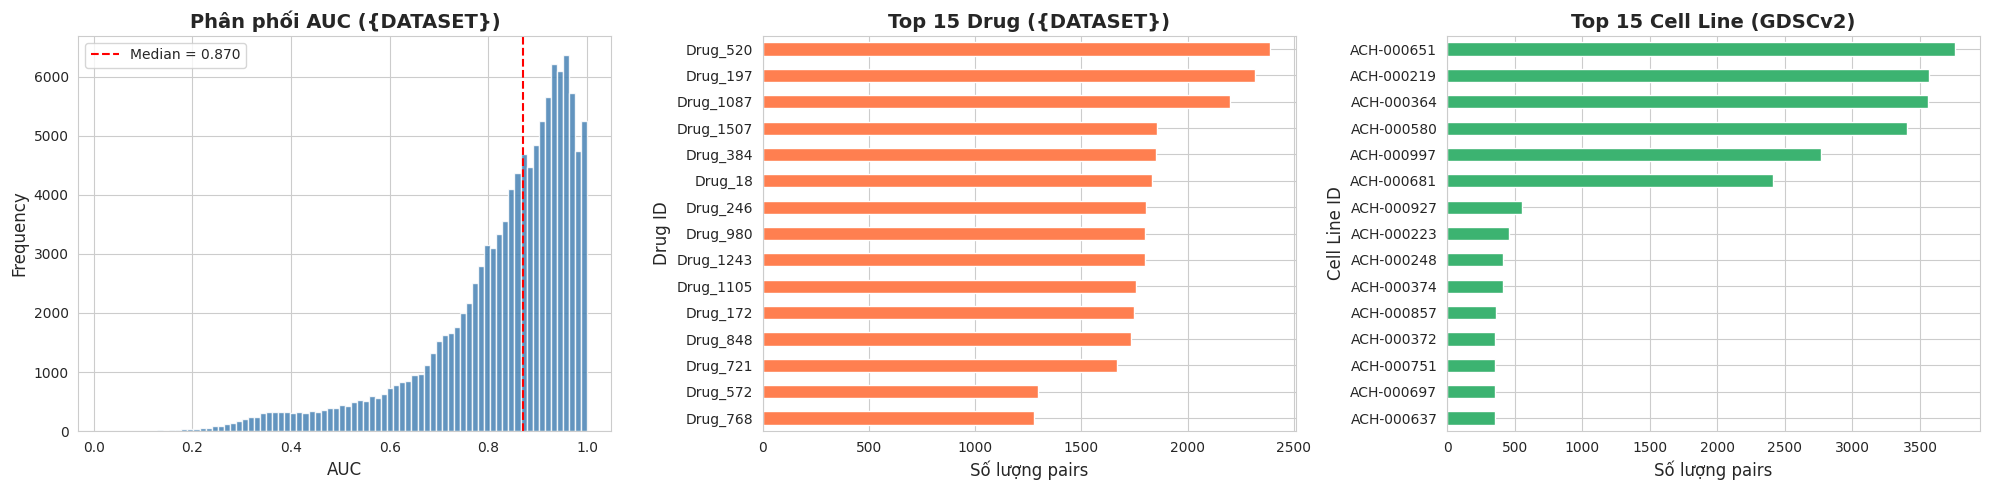

✅ Saved: improve_eda.png


In [4]:
assert 'df_response' in dir(), "❌ Chạy Cell 3 trước."
import matplotlib.pyplot as plt
import seaborn as sns
print("=" * 60)
print(f"       EDA — {DATASET}")
print("=" * 60)
# Load all {DATASET} indices
all_idx_path = f"{BASE}/splits/{DATASET}_all.txt"
try:
    all_idx = pd.read_csv(all_idx_path, header=None)[0].tolist()
    df_eda = df_response.loc[all_idx]
except FileNotFoundError:
    print(f"⚠️ {all_idx_path} không tồn tại, dùng train+val+test thay thế")
    df_eda = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"{DATASET} total: {len(df_eda):,} rows")
print()
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
# Plot 1: Histogram AUC
ax1 = axes[0]
ax1.hist(df_eda[TARGET_COL].dropna(), bins=80, color='steelblue',
         edgecolor='white', alpha=0.85)
median_auc = df_eda[TARGET_COL].median()
ax1.axvline(median_auc, color='red', linestyle='--', linewidth=1.5,
            label=f"Median = {median_auc:.3f}")
ax1.set_title('Phân phối AUC ({DATASET})', fontsize=14, fontweight='bold')
ax1.set_xlabel('AUC', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend(fontsize=10)
# Plot 2: Top 15 Drug
ax2 = axes[1]
top_drugs = df_eda[DRUG_ID_COL].value_counts().head(15)
top_drugs.plot(kind='barh', ax=ax2, color='coral', edgecolor='white')
ax2.set_title('Top 15 Drug ({DATASET})', fontsize=14, fontweight='bold')
ax2.set_xlabel('Số lượng pairs', fontsize=12)
ax2.set_ylabel('Drug ID', fontsize=12)
ax2.invert_yaxis()
# Plot 3: Top 15 Cell Line
ax3 = axes[2]
top_cells = df_eda[CELL_ID_COL].value_counts().head(15)
top_cells.plot(kind='barh', ax=ax3, color='mediumseagreen', edgecolor='white')
ax3.set_title(f'Top 15 Cell Line ({DATASET})', fontsize=14, fontweight='bold')
ax3.set_xlabel('Số lượng pairs', fontsize=12)
ax3.set_ylabel('Cell Line ID', fontsize=12)
ax3.invert_yaxis()
plt.tight_layout()
plt.savefig('improve_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: improve_eda.png")
print("=" * 60)


In [5]:
assert 'df_train' in dir(), "❌ Chạy Cell 3 trước."

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import gc

BASE = "/kaggle/input/datasets/ducer37/improve/csa_data/csa_data/raw_data"

print("=" * 60)
print("       MULTI-OMICS CELL LINE FEATURES")
print("=" * 60)

# ── Config ───────────────────────────────────────────────────────
GE_GENES     = 512    # top GE genes (variance, fit on train only)
MU_TOP       = 256    # top mutation genes (frequency on train)
CNV_GENES    = 256    # top CNV genes (variance on train)
METHYL_GENES = 256    # top methylation sites (variance on train)
# RPPA: dùng toàn bộ columns có đủ data (thường ~200 proteins)

# ── Cell ID sets ─────────────────────────────────────────────────
all_cell_ids   = (set(df_train[CELL_ID_COL]) |
                  set(df_val[CELL_ID_COL])   |
                  set(df_test[CELL_ID_COL]))
train_cell_ids = set(df_train[CELL_ID_COL])

# ── Helper functions ─────────────────────────────────────────────
def load_omics(path, skiprows=None):
    """Load TSV omics file, index = cell ID, columns = features."""
    try:
        df = pd.read_csv(path, sep='\t',
                         skiprows=skiprows if skiprows else None,
                         index_col=0)
        df = df[~df.index.duplicated(keep='first')]
        df = df.apply(pd.to_numeric, errors='coerce')
        return df
    except FileNotFoundError:
        print(f"   ⚠️  File không tồn tại: {path.split('/')[-1]}")
        return None

def select_features(df, all_cells, train_cells, top_k, method='variance'):
    """
    Match cells, chọn top-k features dựa HOÀN TOÀN vào train cells.
    method: 'variance' | 'frequency'
    """
    matched   = df[df.index.isin(all_cells)].copy()
    train_sub = matched[matched.index.isin(train_cells)]

    if method == 'variance':
        scores = train_sub.var(axis=0).fillna(0)
    elif method == 'frequency':
        scores = (train_sub > 0).sum(axis=0)
    else:
        raise ValueError(f"Unknown method: {method}")

    top_feats = scores.nlargest(top_k).index
    selected  = matched[top_feats].copy().fillna(0)

    n_match = len(matched)
    n_unmatched = len(all_cells) - n_match
    print(f"   Matched: {n_match} cells | Unmatched (drop): {n_unmatched} | Features: {top_k}")
    return selected

def fit_transform_scaler(df, train_cells):
    """Fit StandardScaler trên train, transform toàn bộ."""
    scaler    = StandardScaler()
    train_sub = df[df.index.isin(train_cells)]
    scaler.fit(train_sub.values)
    scaled = scaler.transform(df.values).astype(np.float32)
    return scaled, scaler

# ── 1. Gene Expression ───────────────────────────────────────────
print("\n[1/6] Gene Expression")
print("   (skiprows=[1,2] bỏ Entrez ID và Gene name headers)")
df_ge = load_omics(f"{BASE}/x_data/cancer_gene_expression.tsv", skiprows=[1, 2])

ge_dict = {}
GE_DIM  = 0
if df_ge is not None:
    ge_sel      = select_features(df_ge, all_cell_ids, train_cell_ids, GE_GENES, 'variance')
    ge_scaled, _ = fit_transform_scaler(ge_sel, train_cell_ids)
    ge_dict     = dict(zip(ge_sel.index, ge_scaled))
    GE_DIM      = GE_GENES
    print(f"   ✅ GE: {GE_DIM}-dim | scaled mean≈{ge_scaled.mean():.3f}")
    del df_ge, ge_sel, ge_scaled
    gc.collect()

# ── 2. DNA Mutation ──────────────────────────────────────────────
print("\n[2/6] DNA Mutation")
df_mu = load_omics(f"{BASE}/x_data/cancer_mutation_count.tsv", skiprows=[1, 2])

mu_dict = {}
MU_DIM  = 0
if df_mu is not None:
    mu_sel  = select_features(df_mu, all_cell_ids, train_cell_ids, MU_TOP, 'frequency')
    mu_bin  = (mu_sel.values > 0).astype(np.float32)   # binarize: 1=mutated, 0=WT
    mu_dict = dict(zip(mu_sel.index, mu_bin))
    MU_DIM  = MU_TOP
    print(f"   ✅ Mutation: {MU_DIM}-dim (binary) | mut rate≈{mu_bin.mean():.3f}")
    del df_mu, mu_sel, mu_bin
    gc.collect()

# ── 3. Copy Number Variation ─────────────────────────────────────
print("\n[3/6] Copy Number Variation")
cnv_path = f"{BASE}/x_data/cancer_discretized_copy_number.tsv"
# FIX: Thêm skiprows=[1, 2]
df_cnv   = load_omics(cnv_path, skiprows=[1, 2])
if df_cnv is None:
    cnv_path = f"{BASE}/x_data/cancer_copy_number.tsv"
    df_cnv   = load_omics(cnv_path, skiprows=[1, 2])

cnv_dict = {}
CNV_DIM  = 0
if df_cnv is not None:
    cnv_sel  = select_features(df_cnv, all_cell_ids, train_cell_ids, CNV_GENES, 'variance')
    # CNV discretized (-2..2) → dùng trực tiếp, không cần scale
    cnv_arr  = cnv_sel.values.astype(np.float32)
    cnv_dict = dict(zip(cnv_sel.index, cnv_arr))
    CNV_DIM  = CNV_GENES
    print(f"   ✅ CNV: {CNV_DIM}-dim | values range [{cnv_arr.min():.0f}, {cnv_arr.max():.0f}]")
    del df_cnv, cnv_sel, cnv_arr
    gc.collect()

# ── 4. DNA Methylation ───────────────────────────────────────────
print("\n[4/6] DNA Methylation")
df_methyl = load_omics(f"{BASE}/x_data/cancer_DNA_methylation.tsv", skiprows=[1, 2, 3])
methyl_dict = {}
METHYL_DIM  = 0
if df_methyl is not None:
    methyl_sel      = select_features(df_methyl, all_cell_ids, train_cell_ids, METHYL_GENES, 'variance')
    # Fill NaN với median của training trước khi scale
    train_sub_m     = methyl_sel[methyl_sel.index.isin(train_cell_ids)]
    col_medians     = train_sub_m.median(axis=0)
    methyl_sel      = methyl_sel.fillna(col_medians)
    methyl_scaled, _ = fit_transform_scaler(methyl_sel, train_cell_ids)
    methyl_dict     = dict(zip(methyl_sel.index, methyl_scaled))
    METHYL_DIM      = METHYL_GENES
    print(f"   ✅ Methylation: {METHYL_DIM}-dim | scaled mean≈{methyl_scaled.mean():.3f}")
    del df_methyl, methyl_sel, methyl_scaled
    gc.collect()

# ── 5. RPPA Protein Expression ───────────────────────────────────
print("\n[5/6] RPPA Protein Expression")
# FIX: Sửa tên file thành cancer_RPPA.tsv (Không cần skiprows)
df_rppa = load_omics(f"{BASE}/x_data/cancer_RPPA.tsv")
rppa_dict = {}
RPPA_DIM  = 0
if df_rppa is not None:
    rppa_matched = df_rppa[df_rppa.index.isin(all_cell_ids)].copy()
    nan_rate = rppa_matched.isnull().mean(axis=0)
    rppa_matched = rppa_matched.loc[:, nan_rate < 0.3]
    train_rppa   = rppa_matched[rppa_matched.index.isin(train_cell_ids)]
    col_medians  = train_rppa.median(axis=0)
    # FIX: Thêm fillna(0) để bắt những cột toàn NaN
    rppa_matched = rppa_matched.fillna(col_medians).fillna(0) 
    
    rppa_scaled, _ = fit_transform_scaler(rppa_matched, train_cell_ids)
    rppa_dict   = dict(zip(rppa_matched.index, rppa_scaled))
    RPPA_DIM    = rppa_matched.shape[1]
    print(f"   ✅ RPPA: {RPPA_DIM}-dim proteins")
    del df_rppa, rppa_matched, rppa_scaled; gc.collect()
    
# ── 6. miRNA Expression (BỔ SUNG THÊM) ───────────────────────────
print("\n[6/6] miRNA Expression")
df_mirna = load_omics(f"{BASE}/x_data/cancer_miRNA_expression.tsv")
mirna_dict = {}
MIRNA_DIM  = 0
if df_mirna is not None:
    MIRNA_GENES = 256
    mirna_sel = select_features(df_mirna, all_cell_ids, train_cell_ids, MIRNA_GENES, 'variance')
    mirna_scaled, _ = fit_transform_scaler(mirna_sel, train_cell_ids)
    mirna_dict = dict(zip(mirna_sel.index, mirna_scaled))
    MIRNA_DIM  = MIRNA_GENES
    print(f"   ✅ miRNA: {MIRNA_DIM}-dim")
    del df_mirna, mirna_sel, mirna_scaled; gc.collect()
    
# ── Build unified cell_feat_dict ─────────────────────────────────
print("\n--- Building unified cell_feat_dict ---")

# Map từng omics: dict (cell_id → np.array)
all_parts = {
    'GE':         (ge_dict,     GE_DIM),
    'Mutation':   (mu_dict,     MU_DIM),
    'CNV':        (cnv_dict,    CNV_DIM),
    'Methylation':(methyl_dict, METHYL_DIM),
    'RPPA':       (rppa_dict,   RPPA_DIM),
    'miRNA':      (mirna_dict, MIRNA_DIM),
}

# Chỉ dùng omics đã load được
active_parts = {k: v for k, v in all_parts.items() if v[1] > 0}

# Intersection: cell phải có đủ MỌI omics đang dùng
common_cells = all_cell_ids.copy()
for name, (feat_dict, dim) in active_parts.items():
    available = set(feat_dict.keys())
    before    = len(common_cells)
    common_cells = common_cells & available
    dropped   = before - len(common_cells)
    print(f"   After ∩ {name:12s}: {len(common_cells):,} cells (drop {dropped})")

# Nếu RPPA drop quá nhiều, có thể loại bỏ RPPA khỏi intersection
MIN_CELLS = int(len(all_cell_ids) * 0.7)   # giữ ít nhất 70% cell lines
if len(common_cells) < MIN_CELLS and RPPA_DIM > 0:
    print(f"\n   ⚠️  RPPA giảm cells xuống {len(common_cells)} < {MIN_CELLS} (70% threshold)")
    print(f"   ⚠️  Loại RPPA khỏi intersection để giữ đủ samples")
    active_parts.pop('RPPA', None)
    RPPA_DIM = 0
    common_cells = all_cell_ids.copy()
    for name, (feat_dict, dim) in active_parts.items():
        common_cells = common_cells & set(feat_dict.keys())
    print(f"   ✅ Sau khi loại RPPA: {len(common_cells):,} cells")

# Concat tất cả features
cell_feat_dict = {}
for cell_id in common_cells:
    parts_list = []
    for name, (feat_dict, dim) in active_parts.items():
        parts_list.append(feat_dict[cell_id])
    cell_feat_dict[cell_id] = np.concatenate(parts_list)

# ── Summary ──────────────────────────────────────────────────────
CELL_FEAT_DIM_TOTAL = next(iter(cell_feat_dict.values())).shape[0]

print("\n" + "=" * 60)
print("   FEATURE BREAKDOWN")
print("=" * 60)
for name, (_, dim) in active_parts.items():
    bar = '█' * (dim // 32)
    print(f"   {name:15s}: {dim:5d}-dim  {bar}")
print(f"   {'─' * 40}")
print(f"   {'TOTAL':15s}: {CELL_FEAT_DIM_TOTAL:5d}-dim")
print()

n_in_all   = sum(1 for c in all_cell_ids if c in cell_feat_dict)
n_dropped  = len(all_cell_ids) - n_in_all
print(f"   Cell lines có đầy đủ omics : {n_in_all:,}")
print(f"   Cell lines bị drop         : {n_dropped:,}")
print()

sample_id   = next(iter(cell_feat_dict))
sample_feat = cell_feat_dict[sample_id]
print(f"   Sample ({sample_id}): shape={sample_feat.shape}")
print(f"   Values: min={sample_feat.min():.4f}, max={sample_feat.max():.4f}")
print("=" * 60)

       MULTI-OMICS CELL LINE FEATURES

[1/6] Gene Expression
   (skiprows=[1,2] bỏ Entrez ID và Gene name headers)
   Matched: 470 cells | Unmatched (drop): 0 | Features: 512
   ✅ GE: 512-dim | scaled mean≈-0.006

[2/6] DNA Mutation
   Matched: 470 cells | Unmatched (drop): 0 | Features: 256
   ✅ Mutation: 256-dim (binary) | mut rate≈0.214

[3/6] Copy Number Variation
   Matched: 470 cells | Unmatched (drop): 0 | Features: 256
   ✅ CNV: 256-dim | values range [-2, 2]

[4/6] DNA Methylation


/tmp/ipykernel_23/2558317557.py:31: DtypeWarning: Columns (1,2,3,5,6,7,8,9,10,11,12,13,14,17,18,19,20,21,22,23,24,25,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,48,51,53,54,55,56,58,59,60,61,62,63,64,65,66,67,68,69,70,72,73,74,75,76,77,78,79,80,81,82,83,85,86,87,88,89,90,91,93,94,95,96,97,99,100,101,102,103,104,106,107,108,109,110,111,113,114,115,116,117,118,119,120,121,122,123,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,145,147,148,151,152,153,154,156,157,159,160,161,162,163,164,165,166,167,168,169,170,171,172,174,175,176,177,178,179,180,182,183,185,186,187,188,189,190,191,192,193,194,195,197,199,201,202,203,204,205,206,207,208,210,211,212,216,217,218,219,220,222,223,224,225,226,227,228,229,230,231,232,233,234,235,237,238,240,241,242,245,246,247,248,250,251,252,253,254,257,258,259,262,263,264,265,267,269,270,271,272,273,274,275,276,278,279,280,282,283,284,285,286,287,288,289,290,291,292,294,295,296,298,299,300,301,302,305,306,307,308,309,310,31

   Matched: 470 cells | Unmatched (drop): 0 | Features: 256
   ✅ Methylation: 256-dim | scaled mean≈0.007

[5/6] RPPA Protein Expression
   ✅ RPPA: 214-dim proteins

[6/6] miRNA Expression
   Matched: 467 cells | Unmatched (drop): 3 | Features: 256
   ✅ miRNA: 256-dim

--- Building unified cell_feat_dict ---
   After ∩ GE          : 470 cells (drop 0)
   After ∩ Mutation    : 470 cells (drop 0)
   After ∩ CNV         : 470 cells (drop 0)
   After ∩ Methylation : 470 cells (drop 0)
   After ∩ RPPA        : 454 cells (drop 16)
   After ∩ miRNA       : 451 cells (drop 3)

   FEATURE BREAKDOWN
   GE             :   512-dim  ████████████████
   Mutation       :   256-dim  ████████
   CNV            :   256-dim  ████████
   Methylation    :   256-dim  ████████
   RPPA           :   214-dim  ██████
   miRNA          :   256-dim  ████████
   ────────────────────────────────────────
   TOTAL          :  1750-dim

   Cell lines có đầy đủ omics : 451
   Cell lines bị drop         : 19

   Sample 

In [6]:
# ============================================================
#  CELL 6 (REVISED) — SMILES → MOLECULAR GRAPH + ECFP4 FINGERPRINT
#  Thay thế hoàn toàn Cell 6 cũ.
#
#  Cải thiện so với bản gốc:
#   1. Giữ nguyên việc build molecular graph (GCNConv input)
#   2. THÊM Morgan ECFP4 fingerprint (2048-bit) cho mỗi thuốc
#      → lưu vào drug_fp_cache (dùng ở Cell 7 + Cell 9)
#   3. drug_graph_cache vẫn giữ như cũ (tương thích Cell 7)
# ============================================================

assert 'df_train' in dir(), "❌ Chạy Cell 3 trước."
assert 'cell_feat_dict' in dir(), "❌ Chạy Cell 5 trước."

import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data
from rdkit import Chem
from rdkit.Chem import AllChem
from tqdm import tqdm

print("=" * 60)
print("       SMILES → MOLECULAR GRAPH + ECFP4 FINGERPRINT")
print("=" * 60)

# ── Config ───────────────────────────────────────────────────────
FP_RADIUS = 2       # Morgan radius (ECFP4 = radius 2)
FP_NBITS  = 2048    # Fingerprint bit length

# ── Load drug SMILES ─────────────────────────────────────────────
BASE = "/kaggle/input/datasets/ducer37/improve/csa_data/csa_data/raw_data"
df_smiles = pd.read_csv(f"{BASE}/x_data/drug_SMILES.tsv", sep='\t')

assert 'improve_chem_id' in df_smiles.columns
assert 'canSMILES' in df_smiles.columns

drug_smiles_dict = dict(zip(df_smiles['improve_chem_id'], df_smiles['canSMILES']))
print(f"Drug SMILES loaded: {len(drug_smiles_dict):,}")

# ── Xác định drugs cần parse ─────────────────────────────────────
all_drug_ids  = (set(df_train[DRUG_ID_COL]) |
                 set(df_val[DRUG_ID_COL])   |
                 set(df_test[DRUG_ID_COL]))
drugs_to_parse = all_drug_ids & set(drug_smiles_dict.keys())

print(f"Drugs trong splits  : {len(all_drug_ids):,}")
print(f"Drugs có SMILES     : {len(drugs_to_parse):,}")
print(f"Drugs thiếu SMILES  : {len(all_drug_ids - set(drug_smiles_dict.keys())):,}")
print()

# ── Atom / Bond feature functions (giữ nguyên từ Cell 6 gốc) ─────
HYBRIDIZATION_LIST = [
    Chem.rdchem.HybridizationType.S,
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
BOND_TYPE_LIST = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]

def atom_features(atom):
    """Node feature vector (11-dim). Giữ nguyên từ bản gốc."""
    hyb_one_hot = [int(atom.GetHybridization() == h) for h in HYBRIDIZATION_LIST]
    return [
        atom.GetAtomicNum(),
        atom.GetTotalDegree(),
        atom.GetFormalCharge(),
        *hyb_one_hot,
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ]  # 11-dim

def bond_features(bond):
    """Edge feature vector (4-dim). Giữ nguyên từ bản gốc."""
    return [int(bond.GetBondType() == bt) for bt in BOND_TYPE_LIST]

def smiles_to_graph(smiles):
    """SMILES → torch_geometric.data.Data | None. Giữ nguyên từ bản gốc."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None or mol.GetNumAtoms() == 0:
            return None
        x = [atom_features(a) for a in mol.GetAtoms()]
        x = torch.tensor(x, dtype=torch.float)
        edge_indices, edge_attrs = [], []
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bf = bond_features(bond)
            edge_indices.extend([[i, j], [j, i]])
            edge_attrs.extend([bf, bf])
        if edge_indices:
            edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
            edge_attr  = torch.tensor(edge_attrs,   dtype=torch.float)
        else:
            edge_index = torch.zeros((2, 0), dtype=torch.long)
            edge_attr  = torch.zeros((0, 4), dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    except Exception:
        return None

def smiles_to_ecfp4(smiles, n_bits=FP_NBITS, radius=FP_RADIUS):
    """
    SMILES → Morgan ECFP4 fingerprint (numpy array, float32).
    Trả về np.zeros nếu parse lỗi (để không drop thuốc chỉ vì fingerprint).
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.zeros(n_bits, dtype=np.float32)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        return np.array(fp, dtype=np.float32)
    except Exception:
        return np.zeros(n_bits, dtype=np.float32)

# ── Parse drugs ──────────────────────────────────────────────────
drug_graph_cache = {}   # drug_id → Data | None  (graph cho GCN)
drug_fp_cache    = {}   # drug_id → np.array     (fingerprint 2048-dim)

invalid_graphs = []
zero_fp_count  = 0
total_nodes, total_edges = 0, 0

for drug_id in tqdm(drugs_to_parse, desc="SMILES → Graph + FP"):
    smiles = drug_smiles_dict[drug_id]

    # --- Molecular graph ---
    graph = smiles_to_graph(smiles)
    drug_graph_cache[drug_id] = graph
    if graph is None:
        invalid_graphs.append(drug_id)
    else:
        total_nodes += graph.x.shape[0]
        total_edges += graph.edge_index.shape[1]

    # --- ECFP4 Fingerprint ---
    fp = smiles_to_ecfp4(smiles)
    drug_fp_cache[drug_id] = fp
    if fp.sum() == 0:
        zero_fp_count += 1

n_valid = len(drug_graph_cache) - len(invalid_graphs)

print()
print("=" * 60)
print("  MOLECULAR GRAPH")
print(f"  ✅ Valid graphs     : {n_valid:,}")
print(f"  ❌ Invalid SMILES   : {len(invalid_graphs):,}")
if invalid_graphs:
    for did in invalid_graphs[:3]:
        print(f"     {did}: {drug_smiles_dict.get(did, '?')[:50]}")
print(f"  Avg nodes/graph    : {total_nodes / max(n_valid, 1):.1f}")
print(f"  Avg edges/graph    : {total_edges / max(n_valid, 1):.1f}")

print()
print("  ECFP4 FINGERPRINT (Morgan radius=2, bits=2048)")
print(f"  ✅ FP computed      : {len(drug_fp_cache):,}")
print(f"  ⚠️  Zero FP (fallback): {zero_fp_count:,}")

# ── Verify sample ─────────────────────────────────────────────────
sample_did = next(d for d, g in drug_graph_cache.items() if g is not None)
sg  = drug_graph_cache[sample_did]
sfp = drug_fp_cache[sample_did]

print()
print(f"  Sample drug ({sample_did}):")
print(f"    Graph: x={sg.x.shape}, edge_index={sg.edge_index.shape}")
print(f"    FP   : shape={sfp.shape}, bits on={int(sfp.sum())}/{FP_NBITS}")
print(f"    Tanimoto density: {sfp.mean():.3f}")
print("=" * 60)

# ── Load Mordred Descriptors ─────────────────────────────────────
print("\n  MORDRED DESCRIPTORS")
df_mordred = pd.read_csv(f"{BASE}/x_data/drug_mordred.tsv", sep='\t')

# Bỏ cột ID, biến đổi mọi thứ thành dạng số
mordred_cols = [c for c in df_mordred.columns if c != 'improve_chem_id']
for c in mordred_cols:
    df_mordred[c] = pd.to_numeric(df_mordred[c], errors='coerce')

# Fill NaN bằng median của cột, nếu vẫn còn NaN thì fill bằng 0
df_mordred[mordred_cols] = df_mordred[mordred_cols].fillna(df_mordred[mordred_cols].median()).fillna(0)

# Normalize Mordred (vì scale của nó lệch nhau rất lớn)
from sklearn.preprocessing import StandardScaler
# FIX LỖI LEAKAGE: CHỈ FIT MORDRED SCALER TRÊN TRAIN DRUGS
scaler_mordred = StandardScaler()
train_drugs_set = set(df_train[DRUG_ID_COL])
mordred_train_sub = df_mordred[df_mordred['improve_chem_id'].isin(train_drugs_set)][mordred_cols].values
scaler_mordred.fit(mordred_train_sub)
scaled_mordred = scaler_mordred.transform(df_mordred[mordred_cols].values).astype(np.float32)

drug_mordred_cache = dict(zip(df_mordred['improve_chem_id'], scaled_mordred))
MORDRED_DIM = len(mordred_cols)

# Tạo mảng zeros cho các drug bị thiếu Mordred
zero_mordred = np.zeros(MORDRED_DIM, dtype=np.float32)
missing_mordred = sum(1 for d in drugs_to_parse if d not in drug_mordred_cache)

print(f"  ✅ Mordred loaded   : {len(drug_mordred_cache):,} drugs ({MORDRED_DIM}-dim)")
print(f"  ⚠️  Thiếu Mordred    : {missing_mordred:,}")


       SMILES → MOLECULAR GRAPH + ECFP4 FINGERPRINT
Drug SMILES loaded: 1,565
Drugs trong splits  : 168
Drugs có SMILES     : 168
Drugs thiếu SMILES  : 0



SMILES → Graph + FP:   0%|          | 0/168 [00:00<?, ?it/s][11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenerator
[11:37:08] DEPRECATION WARNING: please use MorganGenera


  MOLECULAR GRAPH
  ✅ Valid graphs     : 168
  ❌ Invalid SMILES   : 0
  Avg nodes/graph    : 32.1
  Avg edges/graph    : 70.5

  ECFP4 FINGERPRINT (Morgan radius=2, bits=2048)
  ✅ FP computed      : 168
  ⚠️  Zero FP (fallback): 0

  Sample drug (Drug_36):
    Graph: x=torch.Size([22, 11]), edge_index=torch.Size([2, 48])
    FP   : shape=(2048,), bits on=35/2048
    Tanimoto density: 0.017

  MORDRED DESCRIPTORS
  ✅ Mordred loaded   : 1,565 drugs (1613-dim)
  ⚠️  Thiếu Mordred    : 0


In [7]:
# ============================================================
#  CELL 7 (REVISED) — TẠO DATASET + STRICT FILTER
#  Thay thế Cell 7 cũ.
#
#  Thay đổi so với bản gốc:
#   - Thêm drug_fp (ECFP4) vào mỗi Data object
#   - Cập nhật CELL_FEAT_DIM_TOTAL (thay vì cứng 512)
#   - Strict filter bao gồm kiểm tra drug_fp_cache
# ============================================================

assert 'drug_graph_cache' in dir(), "❌ Chạy Cell 6 trước."
assert 'drug_fp_cache'    in dir(), "❌ Chạy Cell 6 trước."
assert 'cell_feat_dict'   in dir(), "❌ Chạy Cell 5 trước."
assert 'df_train'         in dir(), "❌ Chạy Cell 3 trước."

import torch
import numpy as np
import pandas as pd
from torch_geometric.data import Data
from tqdm import tqdm

print("=" * 60)
print("       TẠO DATASET + STRICT FILTER (với FP)")
print("=" * 60)

def create_data_object(row):
    """
    Tạo 1 Data object từ 1 row.
    Bổ sung: drug_fp từ drug_fp_cache.
    """
    drug_id   = row[DRUG_ID_COL]
    cell_id   = row[CELL_ID_COL]
    auc_value = row[TARGET_COL]
    graph     = drug_graph_cache[drug_id]
    cell_feat = cell_feat_dict[cell_id]
    drug_fp   = drug_fp_cache[drug_id]
    
    # THÊM MỚI: Lấy Mordred an toàn (nếu thiếu thì dùng vector 0)
    mordred_feat = drug_mordred_cache.get(drug_id, zero_mordred)
    data = Data(
        x            = graph.x.clone(),
        edge_index   = graph.edge_index.clone(),
        edge_attr    = graph.edge_attr.clone(),
        cell_feat    = torch.tensor(cell_feat, dtype=torch.float).unsqueeze(0),
        drug_fp      = torch.tensor(drug_fp, dtype=torch.float).unsqueeze(0),
        drug_mordred = torch.tensor(mordred_feat, dtype=torch.float).unsqueeze(0), # ← THÊM MỚI
        y            = torch.tensor([auc_value], dtype=torch.float),
    )
    return data

def build_dataset(df_split, split_name):
    """Filter + tạo Data objects cho 1 split."""
    data_list      = []
    n_drug_drop    = 0
    n_cell_drop    = 0
    n_target_drop  = 0

    for _, row in tqdm(df_split.iterrows(), total=len(df_split),
                       desc=f"Building {split_name}"):
        drug_id = row[DRUG_ID_COL]
        cell_id = row[CELL_ID_COL]

        # Check graph hợp lệ
        if drug_id not in drug_graph_cache or drug_graph_cache[drug_id] is None:
            n_drug_drop += 1
            continue

        # Check fingerprint (sẽ có zero-vector nếu parse lỗi, vẫn dùng được)
        # drug_fp_cache LUÔN có entry cho mọi drug đã qua Cell 6

        # Check cell line có đủ multi-omics
        if cell_id not in cell_feat_dict:
            n_cell_drop += 1
            continue

        # Check target không NaN
        if pd.isna(row[TARGET_COL]):
            n_target_drop += 1
            continue

        data_list.append(create_data_object(row))

    total_drop = n_drug_drop + n_cell_drop + n_target_drop
    pct_keep   = len(data_list) / max(len(df_split), 1) * 100
    print(f"  {split_name:5s}: {len(df_split):>7,} → {len(data_list):>7,} ({pct_keep:.1f}%) "
          f"| drop: drug={n_drug_drop}, cell={n_cell_drop}, nan={n_target_drop}")
    return data_list

# ── Build ─────────────────────────────────────────────────────────
data_train = build_dataset(df_train, "Train")
data_val   = build_dataset(df_val,   "Val")
data_test  = build_dataset(df_test,  "Test")

print()
print("=" * 60)
print(f"  Train : {len(data_train):,}")
print(f"  Val   : {len(data_val):,}")
print(f"  Test  : {len(data_test):,}")
print(f"  TOTAL : {len(data_train) + len(data_val) + len(data_test):,}")
print()

# ── Inspect sample ────────────────────────────────────────────────
sample = data_train[0]
print("--- Sample (train[0]) ---")
print(f"  x (node feat)   : {sample.x.shape}")
print(f"  edge_index      : {sample.edge_index.shape}")
print(f"  edge_attr       : {sample.edge_attr.shape}")
print(f"  cell_feat       : {sample.cell_feat.shape}  ← multi-omics")
print(f"  drug_fp         : {sample.drug_fp.shape}   ← ECFP4 fingerprint")
print(f"  y (AUC)         : {sample.y.item():.4f}")
print()

# ── AUC distribution ──────────────────────────────────────────────
all_y = [d.y.item() for d in data_train]
print(f"  AUC (train): mean={np.mean(all_y):.4f}, std={np.std(all_y):.4f}, "
      f"min={np.min(all_y):.4f}, max={np.max(all_y):.4f}")
print("=" * 60)

       TẠO DATASET + STRICT FILTER (với FP)


Building Train: 100%|██████████| 82548/82548 [00:21<00:00, 3921.66it/s]


  Train:  82,548 →  79,989 (96.9%) | drop: drug=0, cell=2559, nan=0


Building Val: 100%|██████████| 9723/9723 [00:02<00:00, 4516.05it/s]


  Val  :   9,723 →   8,932 (91.9%) | drop: drug=0, cell=791, nan=0


Building Test: 100%|██████████| 22373/22373 [00:05<00:00, 3769.31it/s]


  Test :  22,373 →  21,823 (97.5%) | drop: drug=0, cell=550, nan=0

  Train : 79,989
  Val   : 8,932
  Test  : 21,823
  TOTAL : 110,744

--- Sample (train[0]) ---
  x (node feat)   : torch.Size([26, 11])
  edge_index      : torch.Size([2, 60])
  edge_attr       : torch.Size([60, 4])
  cell_feat       : torch.Size([1, 1750])  ← multi-omics
  drug_fp         : torch.Size([1, 2048])   ← ECFP4 fingerprint
  y (AUC)         : -1.9421

  AUC (train): mean=0.0041, std=0.9970, min=-5.3469, max=1.1309


In [8]:
assert 'data_train' in dir(), "❌ Chạy Cell 7 trước."
from torch_geometric.loader import DataLoader
print("=" * 60)
print("       DATALOADER")
print("=" * 60)
train_loader = DataLoader(data_train, batch_size=64,  shuffle=True)
val_loader   = DataLoader(data_val,   batch_size=128, shuffle=False)
test_loader  = DataLoader(data_test,  batch_size=128, shuffle=False)
print(f"Train : {len(train_loader):,} batches (bs=64)")
print(f"Val   : {len(val_loader):,} batches (bs=128)")
print(f"Test  : {len(test_loader):,} batches (bs=128)")
print()
batch = next(iter(train_loader))
print("--- Batch mẫu (train) ---")
print(f"  batch.x          : {batch.x.shape}")
print(f"  batch.edge_index : {batch.edge_index.shape}")
print(f"  batch.edge_attr  : {batch.edge_attr.shape}")
print(f"  batch.batch      : {batch.batch.shape} (graphs: {batch.batch.max().item()+1})")
print(f"  batch.cell_feat  : {batch.cell_feat.shape}")
print(f"  batch.y          : {batch.y.shape}")
print("=" * 60)

       DATALOADER
Train : 1,250 batches (bs=64)
Val   : 70 batches (bs=128)
Test  : 171 batches (bs=128)

--- Batch mẫu (train) ---
  batch.x          : torch.Size([1959, 11])
  batch.edge_index : torch.Size([2, 4300])
  batch.edge_attr  : torch.Size([4300, 4])
  batch.batch      : torch.Size([1959]) (graphs: 64)
  batch.cell_feat  : torch.Size([64, 1750])
  batch.y          : torch.Size([64])


In [9]:
# ============================================================
#  CELL 9 (REVISED) — MODEL GraphCDR + FP ENCODER
#  Thay thế Cell 9 cũ.
#
#  Thay đổi so với bản gốc:
#   1. GraphCDR thêm fp_encoder: Linear(FP_NBITS → fp_out=64)
#   2. fusion nhận [drug_repr(128) | fp_repr(64) | cell_repr(128)]
#      → tổng input 320-dim thay vì 256-dim
#   3. CELL_FEAT_DIM đọc từ data_train[0] (tự động nhận multi-omics)
#   4. FP_DIM đọc từ data_train[0].drug_fp (tự động)
#   5. Mọi thứ khác (DrugEncoder, CellEncoder, augmentation,
#      NT-Xent loss) giữ NGUYÊN từ bản gốc
# ============================================================

assert 'train_loader' in dir(), "❌ Chạy Cell 8 trước."
assert 'data_train'   in dir(), "❌ Chạy Cell 7 trước."

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, GINEConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("       MODEL GraphCDR + FP ENCODER")
print("=" * 60)
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
print()

# Đọc dims từ data (tự động nhận đúng kích thước)
NODE_FEAT_DIM = data_train[0].x.shape[1]               # 11
CELL_FEAT_DIM = data_train[0].cell_feat.shape[1]        # multi-omics total dim
FP_DIM        = data_train[0].drug_fp.shape[1]          # 2048 (ECFP4)
MORDRED_DIM   = data_train[0].drug_mordred.shape[1]   # ← THÊM MỚI

print(f"Node feat dim  : {NODE_FEAT_DIM}  (atom features)")
print(f"Cell feat dim  : {CELL_FEAT_DIM}  (multi-omics)")
print(f"Drug FP dim    : {FP_DIM}  (ECFP4 fingerprint)")
print()

# ============================================================
# Augmentation: DropNode (GIỐNG HỆT bản gốc)
# ============================================================
def augment_graph(batch, drop_rate=0.1):
    """DropNode augmentation trên batched graph."""
    num_nodes = batch.x.size(0)
    keep_mask = torch.rand(num_nodes, device=batch.x.device) > drop_rate

    for g_idx in range(batch.batch.max().item() + 1):
        graph_mask = (batch.batch == g_idx)
        if (keep_mask & graph_mask).sum() == 0:
            first_node = graph_mask.nonzero(as_tuple=True)[0][0]
            keep_mask[first_node] = True

    node_mapping = torch.full((num_nodes,), -1, dtype=torch.long, device=batch.x.device)
    kept_indices = keep_mask.nonzero(as_tuple=True)[0]
    node_mapping[kept_indices] = torch.arange(kept_indices.size(0), device=batch.x.device)

    ei = batch.edge_index
    edge_keep      = keep_mask[ei[0]] & keep_mask[ei[1]]
    new_edge_index = node_mapping[ei[:, edge_keep]]
    new_edge_attr  = batch.edge_attr[edge_keep] if batch.edge_attr is not None else None

    if new_edge_index.size(1) == 0:
        return batch
    aug_data       = Data(x=batch.x[keep_mask], edge_index=new_edge_index, edge_attr=new_edge_attr)
    aug_data.batch = batch.batch[keep_mask]
    return aug_data

# ============================================================
# NT-Xent Contrastive Loss (GIỐNG HỆT bản gốc)
# ============================================================
def nt_xent_loss(z1, z2, temperature=0.5):
    """NT-Xent loss. z1, z2: [B, dim]."""
    B = z1.size(0)
    if B < 2:
        return torch.tensor(0.0, device=z1.device)
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    z  = torch.cat([z1, z2], dim=0)
    N  = z.size(0)
    sim  = torch.mm(z, z.t()) / temperature
    mask = ~torch.eye(N, dtype=torch.bool, device=z.device)
    idx  = torch.arange(B, device=z.device)
    pos1 = sim[idx, idx + B]
    pos2 = sim[idx + B, idx]
    denom1 = sim[idx].masked_select(mask[idx]).view(B, N - 1)
    denom2 = sim[idx + B].masked_select(mask[idx + B]).view(B, N - 1)
    loss = ((-pos1 + torch.logsumexp(denom1, dim=1)) +
            (-pos2 + torch.logsumexp(denom2, dim=1))).mean() / 2
    return loss

# ============================================================
# DrugEncoder — GIỐNG HỆT bản gốc
# ============================================================
class DrugEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, edge_dim=4, heads=2):
        super().__init__()
        self.conv1 = GATv2Conv(in_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim)
        self.conv2 = GATv2Conv(hidden_dim, hidden_dim // heads, heads=heads, edge_dim=edge_dim)
        self.conv3 = GATv2Conv(hidden_dim, out_dim // heads, heads=heads, edge_dim=edge_dim)
        self.ln1, self.ln2, self.ln3 = nn.LayerNorm(hidden_dim), nn.LayerNorm(hidden_dim), nn.LayerNorm(out_dim)
    def forward(self, x, edge_index, edge_attr, batch):
        x = F.relu(self.ln1(self.conv1(x, edge_index, edge_attr)))
        x = F.relu(self.ln2(self.conv2(x, edge_index, edge_attr)))
        x = F.relu(self.ln3(self.conv3(x, edge_index, edge_attr)))
        return global_max_pool(x, batch)

# ============================================================
# CellEncoder — GIỐNG HỆT bản gốc
# (nhận CELL_FEAT_DIM động, tự động scale với multi-omics)
# ============================================================
class CellEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)

# ============================================================
# GraphCDR — THAY ĐỔI CHÍNH
# Thêm fp_encoder branch (3 dòng trong __init__, 2 dòng trong forward)
# ============================================================
class GraphCDR(nn.Module):
    def __init__(self, node_feat_dim, cell_feat_dim,
                 fp_dim=2048,           # ← THÊM MỚI
                 mordred_dim=1613, 
                 gcn_hidden=256, drug_out=128,
                 cell_hidden=512, cell_out=128,
                 fp_out=64, mordred_out=64,             
                 fusion_hidden=128, dropout=0.107):
        super().__init__()

        self.drug_encoder = DrugEncoder(node_feat_dim, gcn_hidden, drug_out)
        self.cell_encoder = CellEncoder(cell_feat_dim, cell_hidden, cell_out, dropout)

        # ── FP Encoder (THÊM MỚI) ────────────────────────────────
        # Map ECFP4 2048-bit → fp_out (64-dim compact representation)
        self.fp_encoder = nn.Sequential(
            nn.Linear(fp_dim, fp_out * 4),   # 2048 → 256
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fp_out * 4, fp_out),   # 256 → 64
            nn.ReLU(),
        )

        # ── Mordred Encoder (THÊM MỚI) ───────────────────────────
        self.mordred_encoder = nn.Sequential(
            nn.Linear(mordred_dim, mordred_out * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mordred_out * 4, mordred_out),
            nn.ReLU(),
        )

        # ── Fusion (drug_out + fp_out + mordred_out + cell_out) ──
        # 128 + 64 + 64 + 128 = 384
        fusion_in = drug_out + fp_out + mordred_out + cell_out
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1),
        )
    def forward(self, batch):
        # 1. Khử toàn bộ NaN/Inf
        batch.cell_feat = torch.nan_to_num(batch.cell_feat, nan=0.0, posinf=0.0, neginf=0.0)
        batch.drug_mordred = torch.nan_to_num(batch.drug_mordred, nan=0.0, posinf=0.0, neginf=0.0)
        batch.drug_fp = torch.nan_to_num(batch.drug_fp, nan=0.0, posinf=0.0, neginf=0.0)
        batch.x = torch.nan_to_num(batch.x, nan=0.0, posinf=0.0, neginf=0.0)
        
        # 2. Xử lý như bình thường (Giữ nguyên các hàm squeeze của bạn)
        drug_repr = self.drug_encoder(batch.x, batch.edge_index, batch.edge_attr, batch.batch)
        
        cell_feat = batch.cell_feat.squeeze(1)                                  
        cell_repr = self.cell_encoder(cell_feat)                                
        
        fp_feat   = batch.drug_fp.squeeze(1)                                    
        fp_repr   = self.fp_encoder(fp_feat)                                    
        
        mordred_feat = batch.drug_mordred.squeeze(1)                            
        mordred_repr = self.mordred_encoder(mordred_feat)                       
        
        combined  = torch.cat([drug_repr, fp_repr, mordred_repr, cell_repr], dim=1) 
        pred      = self.fusion(combined)                                       
        return pred, drug_repr
    def encode_drug(self, batch):
        batch.x = torch.nan_to_num(batch.x, nan=0.0, posinf=0.0, neginf=0.0)
        return self.drug_encoder(batch.x, batch.edge_index, batch.edge_attr, batch.batch)

# ── Khởi tạo ─────────────────────────────────────────────────────
model = GraphCDR(
    node_feat_dim = NODE_FEAT_DIM,
    cell_feat_dim = CELL_FEAT_DIM,   # tự động nhận multi-omics dim
    fp_dim        = FP_DIM,          # tự động nhận ECFP4 dim
    mordred_dim   = MORDRED_DIM,
).to(DEVICE)

# ── Thống kê params ───────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

# Chi tiết từng module
def count_params(module):
    return sum(p.numel() for p in module.parameters())

print("--- Model architecture ---")
print(model)
print()
print(f"{'Module':20s} {'Params':>10s}")
print("-" * 32)
print(f"{'DrugEncoder (GCN)':20s} {count_params(model.drug_encoder):>10,}")
print(f"{'FP Encoder (MLP)':20s} {count_params(model.fp_encoder):>10,}  ← mới")
print(f"{'CellEncoder (MLP)':20s} {count_params(model.cell_encoder):>10,}")
print(f"{'Fusion':20s} {count_params(model.fusion):>10,}")
print("-" * 32)
print(f"{'TOTAL':20s} {total_params:>10,}")
print()

# ── Verify forward pass ───────────────────────────────────────────
with torch.no_grad():
    sb = next(iter(train_loader)).to(DEVICE)
    pred, drug_repr = model(sb)
    print(f"✅ Forward OK:")
    print(f"   batch.cell_feat : {sb.cell_feat.shape}")
    print(f"   batch.drug_fp   : {sb.drug_fp.shape}")
    print(f"   pred            : {pred.shape}")
    print(f"   drug_repr       : {drug_repr.shape}")
print("=" * 60)

       MODEL GraphCDR + FP ENCODER
Device: cuda
GPU   : Tesla T4

Node feat dim  : 11  (atom features)
Cell feat dim  : 1750  (multi-omics)
Drug FP dim    : 2048  (ECFP4 fingerprint)

--- Model architecture ---
GraphCDR(
  (drug_encoder): DrugEncoder(
    (conv1): GATv2Conv(11, 128, heads=2)
    (conv2): GATv2Conv(256, 128, heads=2)
    (conv3): GATv2Conv(256, 64, heads=2)
    (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (ln3): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (cell_encoder): CellEncoder(
    (net): Sequential(
      (0): Linear(in_features=1750, out_features=512, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.107, inplace=False)
      (3): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (fp_encoder): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.107, inplace=False)
    (3): Linear(in_feat

       TRAINING GraphCDR
Epochs    : 100
LR        : 0.00010124
Patience  : 20
CL weight : 0.1
Device    : cuda

   Epoch |  Train Loss |  Val RMSE |   Val R |   Time
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


    1/100 |    0.826359 |  0.609022 |  0.7917 |  43.3s ★
    2/100 |    0.681223 |  0.598538 |  0.8009 |  42.7s ★
    3/100 |    0.629257 |  0.592876 |  0.8041 |  42.3s ★
    4/100 |    0.629962 |  0.599270 |  0.7986 |  42.1s
    5/100 |    0.627993 |  0.590465 |  0.8053 |  42.2s ★
    6/100 |    0.627555 |  0.596700 |  0.8022 |  42.5s
    7/100 |    0.642001 |  0.585126 |  0.8094 |  42.4s ★
    8/100 |    0.640643 |  0.588906 |  0.8072 |  42.4s
    9/100 |    0.651850 |  0.588777 |  0.8070 |  42.5s
   10/100 |    0.644626 |  0.587894 |  0.8072 |  42.4s
   11/100 |    0.650243 |  0.590529 |  0.8052 |  42.2s
   12/100 |    0.648781 |  0.585598 |  0.8093 |  42.2s
   13/100 |    0.646277 |  0.591816 |  0.8053 |  42.5s
   14/100 |    0.645725 |  0.589752 |  0.8077 |  42.2s
   15/100 |    0.644667 |  0.588547 |  0.8066 |  42.4s
   16/100 |    0.641443 |  0.595324 |  0.8031 |  42.4s
   17/100 |    0.638241 |  0.585726 |  0.8087 |  42.6s
   18/100 |    0.635600 |  0.586788 |  0.8083 |  42.6s


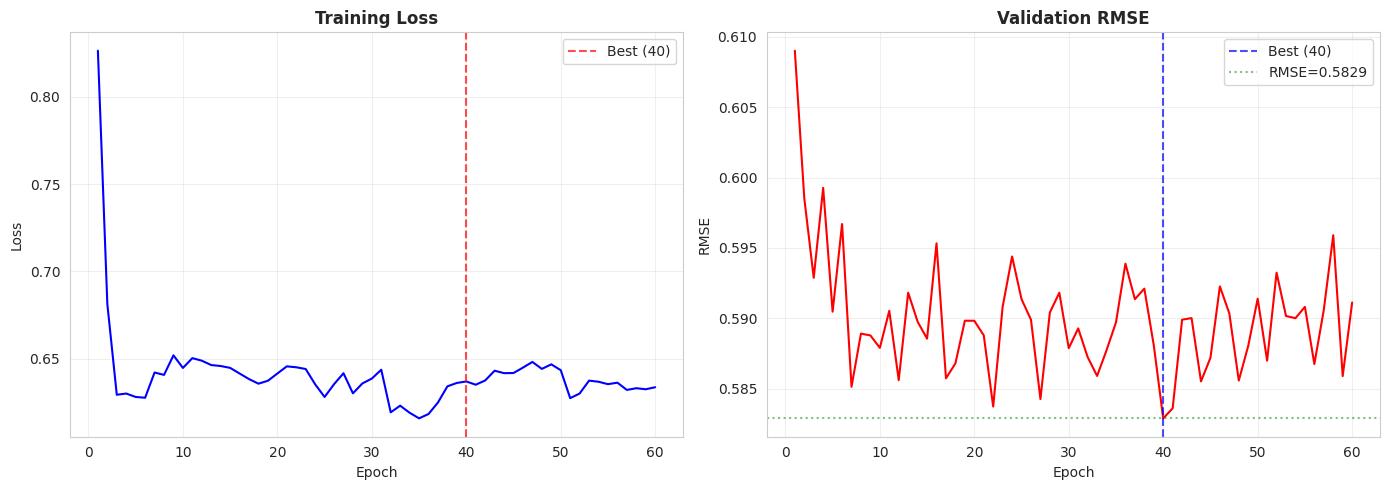

✅ Saved: training_curves_improve.png


In [10]:
assert 'model' in dir(), "❌ Chạy Cell 9 trước."

import time
import numpy as np
from scipy.stats import pearsonr

print("=" * 60)
print("       TRAINING GraphCDR")
print("=" * 60)

EPOCHS             = 100
LR                 = 0.00010124
WEIGHT_DECAY       = 0.0000107
PATIENCE           = 20
CONTRASTIVE_WEIGHT = 0.1
MODEL_PATH         = 'best_model_improve.pth'

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
mse_criterion = nn.MSELoss()

print(f"Epochs    : {EPOCHS}")
print(f"LR        : {LR}")
print(f"Patience  : {PATIENCE}")
print(f"CL weight : {CONTRASTIVE_WEIGHT}")
print(f"Device    : {DEVICE}")
print()

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred, drug_repr = model(batch)
        target = torch.nan_to_num(batch.y.squeeze(), nan=0.0, posinf=0.0, neginf=0.0)
        mse_loss = mse_criterion(pred.squeeze(), target)

        cl_loss = torch.tensor(0.0, device=device)
        bs = batch.y.size(0)
        if bs >= 8:
            try:
                aug = augment_graph(batch, drop_rate=0.1).to(device)
                drug_repr_aug = model.encode_drug(aug)
                ms = min(drug_repr.size(0), drug_repr_aug.size(0))
                if ms >= 2:
                    cl_loss = nt_xent_loss(drug_repr[:ms], drug_repr_aug[:ms])
            except Exception:
                cl_loss = torch.tensor(0.0, device=device)

        loss = mse_loss + CONTRASTIVE_WEIGHT * cl_loss

        # ✅ FIX: Kiểm tra NaN TRƯỚC khi backward để bảo vệ trọng số
        if torch.isnan(loss) or torch.isinf(loss):
            continue   # Bỏ qua batch hỏng, KHÔNG backward

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        n += 1
    return total_loss / max(n, 1)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    preds_list, targets_list = [], []
    for batch in loader:
        batch = batch.to(device)
        pred, _ = model(batch)
        preds_list.append(pred.squeeze().cpu().numpy())
        targets_list.append(batch.y.squeeze().cpu().numpy())

    preds   = np.concatenate(preds_list)
    targets = np.concatenate(targets_list)

    # ✅ FIX: Lọc NaN trước khi tính metrics
    mask    = np.isfinite(preds) & np.isfinite(targets)
    preds   = preds[mask]
    targets = targets[mask]

    if len(preds) == 0:
        return {'MSE': np.inf, 'RMSE': np.inf, 'MAE': np.inf, 'R': 0.0,
                'preds': preds, 'targets': targets}

    mse  = np.mean((preds - targets) ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(preds - targets))
    r, _ = pearsonr(preds, targets)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R': r,
            'preds': preds, 'targets': targets}


# --- Training loop ---
train_losses, val_rmses = [], []
best_val_rmse = float('inf')
patience_counter = 0
best_epoch = 0

print(f"{'Epoch':>8} | {'Train Loss':>11} | {'Val RMSE':>9} | {'Val R':>7} | {'Time':>6}")
print("-" * 60)

try:
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
        val_res = evaluate(model, val_loader, DEVICE)
        elapsed = time.time() - t0

        train_losses.append(train_loss)
        val_rmses.append(val_res['RMSE'])

        if val_res['RMSE'] < best_val_rmse:
            best_val_rmse = val_res['RMSE']
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), MODEL_PATH)
            marker = " ★"
        else:
            patience_counter += 1
            marker = ""

        print(f"  {epoch:3d}/{EPOCHS} | {train_loss:11.6f} | {val_res['RMSE']:9.6f} | "
              f"{val_res['R']:7.4f} | {elapsed:5.1f}s{marker}")

        if patience_counter >= PATIENCE:
            print(f"\n⏹  Early stopping at epoch {epoch}")
            break

except KeyboardInterrupt:
    print(f"\n⏸  Interrupted at epoch {epoch}")

print()
print(f"✅ Best: epoch {best_epoch}, Val RMSE = {best_val_rmse:.6f}")
print(f"   Saved: {MODEL_PATH}")
print()

# --- Loss curves ---
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(train_losses)+1), train_losses, 'b-', lw=1.5)
ax1.axvline(best_epoch, color='red', ls='--', alpha=0.7, label=f'Best ({best_epoch})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('Training Loss', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(range(1, len(val_rmses)+1), val_rmses, 'r-', lw=1.5)
ax2.axvline(best_epoch, color='blue', ls='--', alpha=0.7, label=f'Best ({best_epoch})')
ax2.axhline(best_val_rmse, color='green', ls=':', alpha=0.5, label=f'RMSE={best_val_rmse:.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('RMSE'); ax2.set_title('Validation RMSE', fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_improve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: training_curves_improve.png")
print("=" * 60)

       EVALUATION — TEST SET
✅ Loaded: best_model_improve.pth

╔═══════════════════════════════════╗
║       TEST SET RESULTS            ║
╠═══════════════════════════════════╣
║ Samples    :   21,823            ║
║ MSE        :   0.008756          ║
║ RMSE       :   0.093573          ║
║ MAE        :   0.067924          ║
║ R²         :   0.652711          ║
║ Pearson R  :   0.810078 (p=0.0e+00) ║
║ Spearman R :   0.732684 (p=0.0e+00) ║
╚═══════════════════════════════════╝



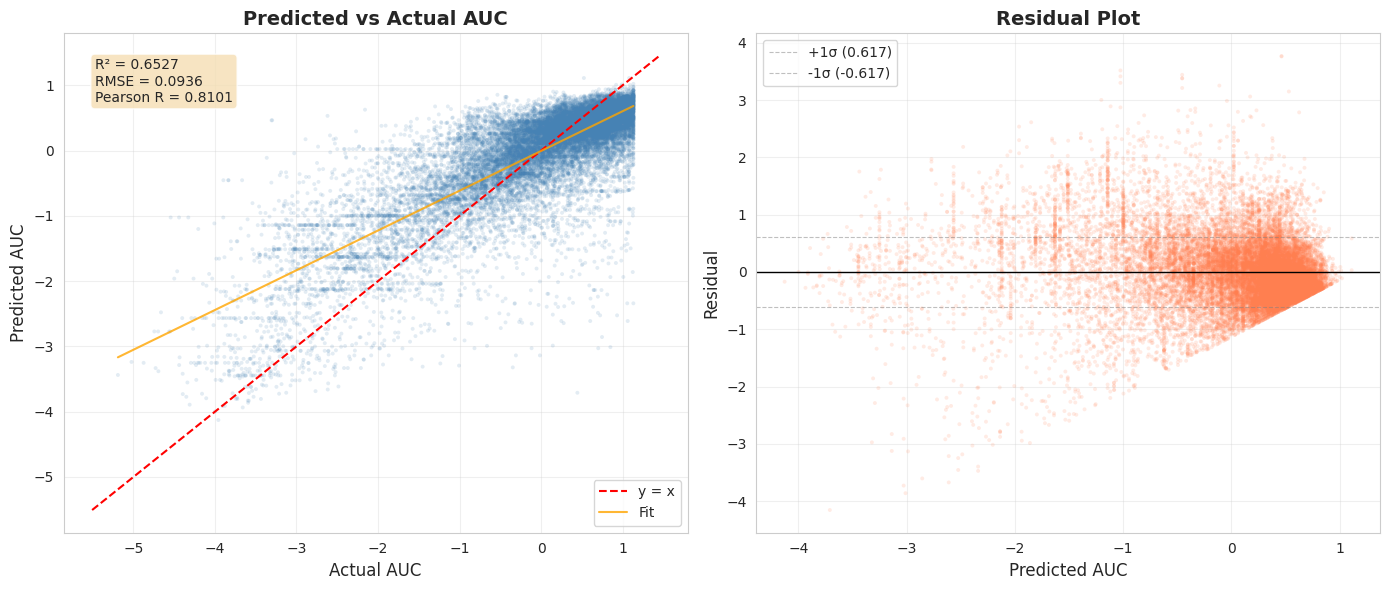


✅ Saved: test_evaluation_improve.png

🎉 Pipeline IMPROVE hoàn tất!
   Cell 1    : Cài đặt
   Cell 2    : Khám phá dữ liệu
   Cell 3    : Load response + splits
   Cell 4    : EDA
   Cell 5    : Cell line features (GE top 512)
   Cell 6    : SMILES → Graph
   Cell 7    : Dataset + strict filter
   Cell 8    : DataLoader
   Cell 9    : Model GraphCDR
   Cell 10   : Training
   Cell 11   : Evaluation


In [11]:
assert 'model' in dir(), "❌ Chạy Cell 9 trước."
assert 'test_loader' in dir(), "❌ Chạy Cell 8 trước."
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score
print("=" * 60)
print("       EVALUATION — TEST SET")
print("=" * 60)
# Load best model
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f"✅ Loaded: {MODEL_PATH}")
print()
# Predict
preds_list, targets_list = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        pred, _ = model(batch)
        preds_list.append(pred.squeeze().cpu().numpy())
        targets_list.append(batch.y.squeeze().cpu().numpy())
preds = np.concatenate(preds_list)
targets = np.concatenate(targets_list)

# 1. BẮT LỖI NaN THẦM LẶNG
mask = np.isfinite(preds) & np.isfinite(targets)
preds = preds[mask]
targets = targets[mask]
if len(preds) == 0:
    print("❌ TOÀN BỘ PREDICTIONS LÀ NaN!")
    preds = np.zeros_like(targets)

# 2. INVERSE TRANSFORM (KÉO VỀ KHÔNG GIAN GỐC ĐỂ TÍNH METRIC)
preds_orig   = (preds * TARGET_STD) + TARGET_MEAN
targets_orig = (targets * TARGET_STD) + TARGET_MEAN

# 3. TÍNH METRICS TRÊN KHÔNG GIAN GỐC
mse = np.mean((preds_orig - targets_orig) ** 2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(preds_orig - targets_orig))
pearson_r, pearson_p = pearsonr(preds_orig, targets_orig)
spearman_r, spearman_p = spearmanr(preds_orig, targets_orig)
r_squared = r2_score(targets_orig, preds_orig) # Sửa lỗi R2

print("╔═══════════════════════════════════╗")
print("║       TEST SET RESULTS            ║")
print("╠═══════════════════════════════════╣")
print(f"║ Samples    : {len(preds):>8,}            ║")
print(f"║ MSE        : {mse:>10.6f}          ║")
print(f"║ RMSE       : {rmse:>10.6f}          ║")
print(f"║ MAE        : {mae:>10.6f}          ║")
print(f"║ R²         : {r_squared:>10.6f}          ║")
print(f"║ Pearson R  : {pearson_r:>10.6f} (p={pearson_p:.1e}) ║")
print(f"║ Spearman R : {spearman_r:>10.6f} (p={spearman_p:.1e}) ║")
print("╚═══════════════════════════════════╝")
print()
# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Scatter: Predicted vs Actual
ax1 = axes[0]
ax1.scatter(targets, preds, alpha=0.15, s=8, color='steelblue', edgecolors='none')
vmin = min(targets.min(), preds.min())
vmax = max(targets.max(), preds.max())
margin = (vmax - vmin) * 0.05
ax1.plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin],
         'r--', lw=1.5, label='y = x')
z = np.polyfit(targets, preds, 1)
xfit = np.linspace(vmin, vmax, 100)
ax1.plot(xfit, np.poly1d(z)(xfit), 'orange', lw=1.5, alpha=0.8, label='Fit')
ax1.set_xlabel('Actual AUC', fontsize=12)
ax1.set_ylabel('Predicted AUC', fontsize=12)
ax1.set_title('Predicted vs Actual AUC', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
txt = f'R² = {r_squared:.4f}\nRMSE = {rmse:.4f}\nPearson R = {pearson_r:.4f}'
ax1.text(0.05, 0.95, txt, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
ax1.grid(True, alpha=0.3)
# Residual plot
ax2 = axes[1]
residuals = preds - targets
ax2.scatter(preds, residuals, alpha=0.15, s=8, color='coral', edgecolors='none')
ax2.axhline(0, color='black', lw=1)
rstd = np.std(residuals)
ax2.axhline(rstd, color='gray', lw=0.8, ls='--', alpha=0.5, label=f'+1σ ({rstd:.3f})')
ax2.axhline(-rstd, color='gray', lw=0.8, ls='--', alpha=0.5, label=f'-1σ ({-rstd:.3f})')
ax2.set_xlabel('Predicted AUC', fontsize=12)
ax2.set_ylabel('Residual', fontsize=12)
ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('test_evaluation_improve.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print("✅ Saved: test_evaluation_improve.png")
print("=" * 60)
print()
print("🎉 Pipeline IMPROVE hoàn tất!")
print("   Cell 1    : Cài đặt")
print("   Cell 2    : Khám phá dữ liệu")
print("   Cell 3    : Load response + splits")
print("   Cell 4    : EDA")
print("   Cell 5    : Cell line features (GE top 512)")
print("   Cell 6    : SMILES → Graph")
print("   Cell 7    : Dataset + strict filter")
print("   Cell 8    : DataLoader")
print("   Cell 9    : Model GraphCDR")
print("   Cell 10   : Training")
print("   Cell 11   : Evaluation")


In [12]:
# ============================================================
#  CELL 12 — CROSS-DATASET EVALUATION (KIỂM CHỨNG BENCHMARK)
# ============================================================
assert 'model' in dir(), "❌ Bạn cần chạy Cell Training trước."

EXTERNAL_DATASET = 'CCLE'  # ĐỔI TÊN Ở ĐÂY: có thể thử 'CCLE', 'gCSI', 'CTRPv2'

print("=" * 60)
print(f"       CROSS-DATASET EVALUATION: {EXTERNAL_DATASET}")
print("=" * 60)

# 1. Load File Split của Dataset bên ngoài
ext_idx_path = f"{BASE}/splits/{EXTERNAL_DATASET}_all.txt"
try:
    ext_idx = pd.read_csv(ext_idx_path, header=None)[0].tolist()
    # Load lại từ file tổng (vì df_response cũ chỉ chứa GDSC)
    df_response_raw = pd.read_csv(f"{BASE}/y_data/response.tsv", sep='\t')
    df_ext = df_response_raw.loc[ext_idx].reset_index(drop=True)
    print(f"✅ Đã load {EXTERNAL_DATASET}: {len(df_ext):,} cặp Thuốc-Tế bào")
except FileNotFoundError:
    print(f"❌ Không tìm thấy file split cho {EXTERNAL_DATASET}. Hãy kiểm tra lại tên.")
    df_ext = pd.DataFrame()

if not df_ext.empty:
    # 2. Lọc ra những Drug và Cell ĐÃ ĐƯỢC XỬ LÝ FEATURES (có sẵn trong Cache)
    # Lý do: Ta không scale lại omics cho tập test lạ để tránh Data Leakage
    valid_drugs = set(drug_graph_cache.keys())
    valid_cells = set(cell_feat_dict.keys())
    
    df_ext_filtered = df_ext[
        df_ext[DRUG_ID_COL].isin(valid_drugs) & 
        df_ext[CELL_ID_COL].isin(valid_cells)
    ].copy()
    
    print(f"   Giữ lại được {len(df_ext_filtered):,} pairs có sẵn Features (Bỏ qua {len(df_ext) - len(df_ext_filtered):,})")
    
    if len(df_ext_filtered) > 0:
        # 3. Z-score Normalize target 
        # CỰC QUAN TRỌNG: Phải dùng TARGET_MEAN và TARGET_STD của tập Train GDSC ban đầu
        df_ext_filtered[TARGET_COL] = (df_ext_filtered[TARGET_COL] - TARGET_MEAN) / TARGET_STD
        
        # 4. Đóng gói thành DataLoader
        data_ext = build_dataset(df_ext_filtered, f"{EXTERNAL_DATASET}")
        ext_loader = DataLoader(data_ext, batch_size=128, shuffle=False)
        
        # 5. Đưa vào Model dự đoán
        print(f"\n🚀 Đang chạy dự đoán trên {EXTERNAL_DATASET}...")
        model.eval()
        preds_list, targets_list = [], []
        with torch.no_grad():
            for batch in ext_loader:
                batch = batch.to(DEVICE)
                pred, _ = model(batch)
                preds_list.append(pred.squeeze().cpu().numpy())
                targets_list.append(batch.y.squeeze().cpu().numpy())
                
        preds = np.concatenate(preds_list)
        targets = np.concatenate(targets_list)
        
        # 6. Bắt lỗi NaN & Kéo về không gian AUC Gốc (Inverse Transform)
        mask = np.isfinite(preds) & np.isfinite(targets)
        preds, targets = preds[mask], targets[mask]
        
        preds_orig = (preds * TARGET_STD) + TARGET_MEAN
        targets_orig = (targets * TARGET_STD) + TARGET_MEAN
        
        # 7. Tính Toán Metrics Chuẩn
        from sklearn.metrics import r2_score
        mse = np.mean((preds_orig - targets_orig) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(preds_orig - targets_orig))
        pearson_r, pearson_p = pearsonr(preds_orig, targets_orig)
        spearman_r, spearman_p = spearmanr(preds_orig, targets_orig)
        r_squared = r2_score(targets_orig, preds_orig)
        
        print("\n╔════════════════════════════════════════════╗")
        print(f"║   CROSS-DATASET: {EXTERNAL_DATASET:<25} ║")
        print("╠════════════════════════════════════════════╣")
        print(f"║ Samples    : {len(preds_orig):>10,}                 ║")
        print(f"║ RMSE       : {rmse:>10.6f}                 ║")
        print(f"║ MAE        : {mae:>10.6f}                 ║")
        print(f"║ R²         : {r_squared:>10.6f}                 ║")
        print(f"║ Pearson R  : {pearson_r:>10.6f}                 ║")
        print("╚════════════════════════════════════════════╝")


       CROSS-DATASET EVALUATION: CCLE


/tmp/ipykernel_23/3831640373.py:17: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_response_raw = pd.read_csv(f"{BASE}/y_data/response.tsv", sep='\t')


✅ Đã load CCLE: 9,519 cặp Thuốc-Tế bào
   Giữ lại được 3,003 pairs có sẵn Features (Bỏ qua 6,516)


Building CCLE: 100%|██████████| 3003/3003 [00:00<00:00, 5099.44it/s]


  CCLE :   3,003 →   3,003 (100.0%) | drop: drug=0, cell=0, nan=0

🚀 Đang chạy dự đoán trên CCLE...

╔════════════════════════════════════════════╗
║   CROSS-DATASET: CCLE                      ║
╠════════════════════════════════════════════╣
║ Samples    :      3,003                 ║
║ RMSE       :   0.115935                 ║
║ MAE        :   0.084653                 ║
║ R²         :   0.556530                 ║
║ Pearson R  :   0.785314                 ║
╚════════════════════════════════════════════╝
